Removed 39 outliers out of 2614 samples.
Random Forest (Normal Damages, With Outliers) -> R2: 0.332, RMSE: 1165148.54


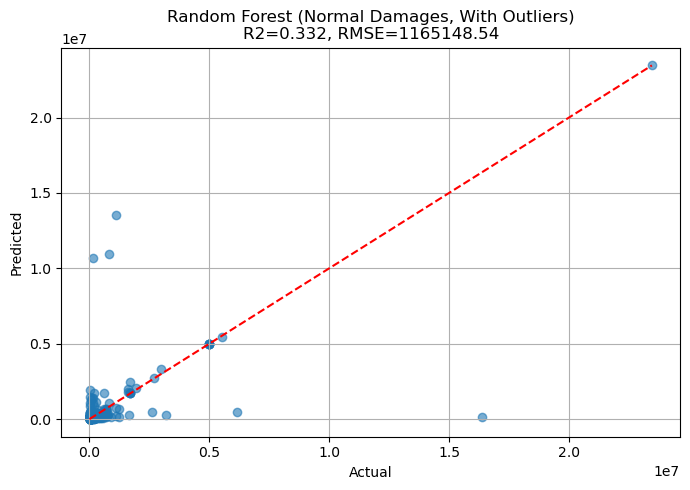

Random Forest (Normal Damages, No Outliers) -> R2: 0.350, RMSE: 249781.14


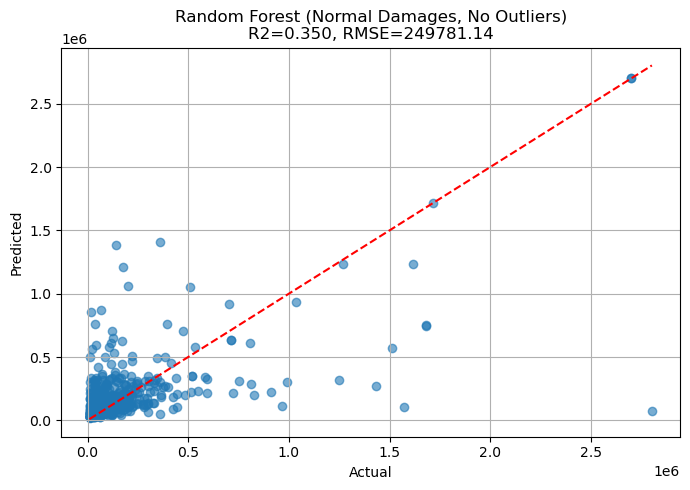

Random Forest (Log Damages, With Outliers) -> R2: 0.519, RMSE: 0.94


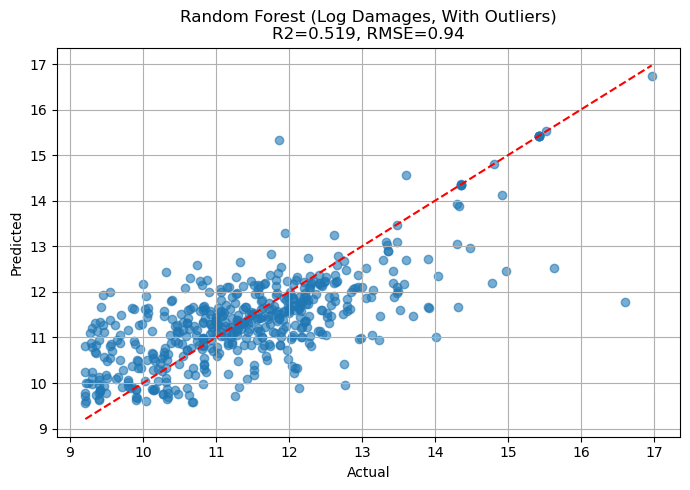

Random Forest (Log Damages, No Outliers) -> R2: 0.402, RMSE: 0.88


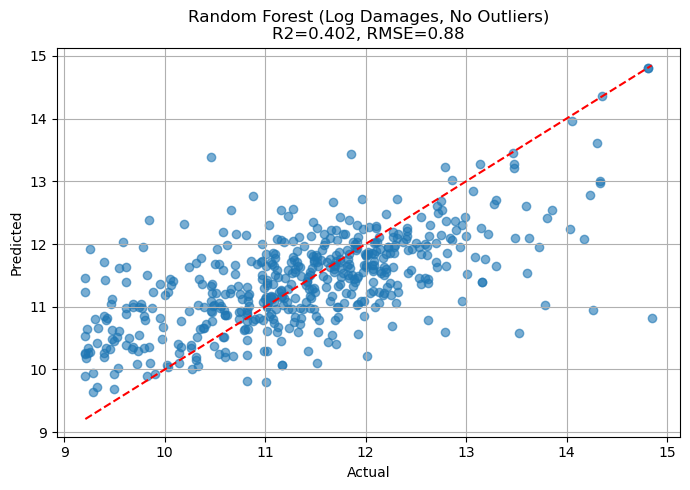


=== Final R² Results ===
Normal (With Outliers):   0.332
Normal (No Outliers):     0.350
Log (With Outliers):      0.519
Log (No Outliers):        0.402


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


# 1. Load and clean dataset
df = pd.read_excel("downsample_correct_columns.xlsx")

df = df.dropna(subset=[
    "Incident State",
    "Date Of Incident",
    "Quantity Released",
    "Unit Of Measure",
    "Hazardous Class",
    "Time Of Incident",
    "Mode Of Transportation",
    "Total Evacuation Hours",
    "Public Evacuated",
    "Major Artery Hours Closed",
    "Undeclared Hazmat Shipment Ind",
    "Total Amount Of Damages"
])

# Convert and extract temporal features
df["Date Of Incident"] = pd.to_datetime(df["Date Of Incident"])
df["Incident Month"] = df["Date Of Incident"].dt.month

# Remove non-numeric hazard classes
df = df[df["Hazardous Class"].apply(lambda v: not isinstance(v, str))]

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Date Of Incident'].dt.month.apply(get_season)

def get_time_of_day(time):
    t = int(time)
    hour = t // 100
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 14:
        return 'Noon'
    elif 14 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 22:
        return 'Evening'
    else:
        return 'Night'

df['Time Of Day'] = df['Time Of Incident'].apply(get_time_of_day)
df = df.drop(['Date Of Incident', 'Time Of Incident'], axis=1)

# 2. Encode and prepare data
X = pd.get_dummies(df.drop(columns=['Total Amount Of Damages']), drop_first=True)
y = df['Total Amount Of Damages']

# 3. Remove outliers
mean = y.mean()
std = y.std()

z_scores = (y - mean) / std
mask = abs(z_scores) < 2
X_no_outliers, y_no_outliers = X[mask], y[mask]

print(f"Removed {len(y) - len(y_no_outliers)} outliers out of {len(y)} samples.")

# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(X_no_outliers, y_no_outliers, test_size=0.2, random_state=42)


# 5. Model evaluation helper
def evaluate_and_plot(model, X_train, X_test, y_train, y_test, title):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    print(f"{title} -> R2: {r2:.3f}, RMSE: {rmse:.2f}")
    
    plt.figure(figsize=(7,5))
    plt.scatter(y_test, y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{title}\nR2={r2:.3f}, RMSE={rmse:.2f}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return r2

# 6. Random Forest models
rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Normal damages with outliers
r2_normal_with = evaluate_and_plot(rf, X_train, X_test, y_train, y_test, "Random Forest (Normal Damages, With Outliers)")

# Normal damages without outliers
r2_normal_no = evaluate_and_plot(rf, X_train_no, X_test_no, y_train_no, y_test_no, "Random Forest (Normal Damages, No Outliers)")

# Log damages with outliers
y_log = np.log1p(y)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)
r2_log_with = evaluate_and_plot(rf, X_train_log, X_test_log, y_train_log, y_test_log, "Random Forest (Log Damages, With Outliers)")

# Log damages without outliers
y_no_outliers_log = np.log1p(y_no_outliers)
X_train_no_log, X_test_no_log, y_train_no_log, y_test_no_log = train_test_split(X_no_outliers, y_no_outliers_log, test_size=0.2, random_state=42)
r2_log_no = evaluate_and_plot(rf, X_train_no_log, X_test_no_log, y_train_no_log, y_test_no_log, "Random Forest (Log Damages, No Outliers)")

# 7. Summary of R² scores
print("\n=== Final R² Results ===")
print(f"Normal (With Outliers):   {r2_normal_with:.3f}")
print(f"Normal (No Outliers):     {r2_normal_no:.3f}")
print(f"Log (With Outliers):      {r2_log_with:.3f}")
print(f"Log (No Outliers):        {r2_log_no:.3f}")
